# 01 — Exploración de contaminantes del aire en Lima

Este notebook explora las mediciones de calidad del aire de SENAMHI: PM10, PM2.5 y NO2, hora a hora, en 7 estaciones de Lima entre enero de 2015 y mayo de 2024.

Los datos ya vienen limpios del pipeline (`src/limpieza.py`): timestamps convertidos de UTC a hora de Lima, sin duplicados y con los valores físicamente imposibles anulados. Las decisiones de limpieza están en `Docs/5_decisiones.md`.

In [1]:
# cargar librerias y datos procesados
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_parquet(RAIZ / "datos" / "procesados" / "contaminantes.parquet")

# agregar columnas de tiempo utiles para el analisis
df["anio"] = df.fecha_hora.dt.year
df["mes"] = df.fecha_hora.dt.month
df["hora"] = df.fecha_hora.dt.hour
df["dia_semana"] = df.fecha_hora.dt.dayofweek

print(f"filas: {len(df):,}")
print(f"rango: {df.fecha_hora.min()} a {df.fecha_hora.max()}")
print(f"estaciones: {sorted(df.estacion.unique())}")

filas: 577,710
rango: 2015-01-01 00:00:00 a 2024-05-31 18:00:00
estaciones: ['CAMPO_DE_MARTE', 'CARABAYLLO', 'SANTA_ANITA', 'SAN_BORJA', 'SAN_JUAN_DE_LURIGANCHO', 'SAN_MARTIN_DE_PORRES', 'VILLA_MARIA_DEL_TRIUNFO']


## 1. Panorama general por estación

Promedios del periodo completo. Como referencia: la guía anual de la OMS (2021) para PM2.5 es 5 µg/m³; el estándar legal peruano (ECA), 25.

In [2]:
# resumir la media del periodo completo por estacion
medias = (
    df.groupby(["estacion", "distrito"])[["pm10", "pm2_5", "no2"]]
    .mean()
    .round(1)
    .sort_values("pm2_5", ascending=False)
)
medias

,,pm10,pm2_5,no2
estacion,distrito,,,
SAN_JUAN_DE_LURIGANCHO,SAN_JUAN_DE_LURIGANCHO,75.0,31.4,31.4
SANTA_ANITA,SANTA_ANITA,62.9,30.0,25.4
CARABAYLLO,CARABAYLLO,71.8,27.9,22.6
VILLA_MARIA_DEL_TRIUNFO,VILLA_MARIA_DEL_TRIUNFO,97.7,26.2,17.7
SAN_BORJA,SAN_BORJA,58.8,18.7,21.0
SAN_MARTIN_DE_PORRES,SAN_MARTIN_DE_PORRES,41.5,18.7,23.1
CAMPO_DE_MARTE,JESUS_MARIA,30.7,16.9,17.9


La brecha dentro de la misma ciudad es grande. San Juan de Lurigancho promedia 31.4 µg/m³ de PM2.5, casi el doble que Campo de Marte (16.9) y más de seis veces la guía OMS. En PM10 el caso extremo es Villa María del Triunfo (97.7), donde pesa el polvo que levantan las vías sin asfaltar de las laderas.

## 2. Evolución temporal 2015–2024

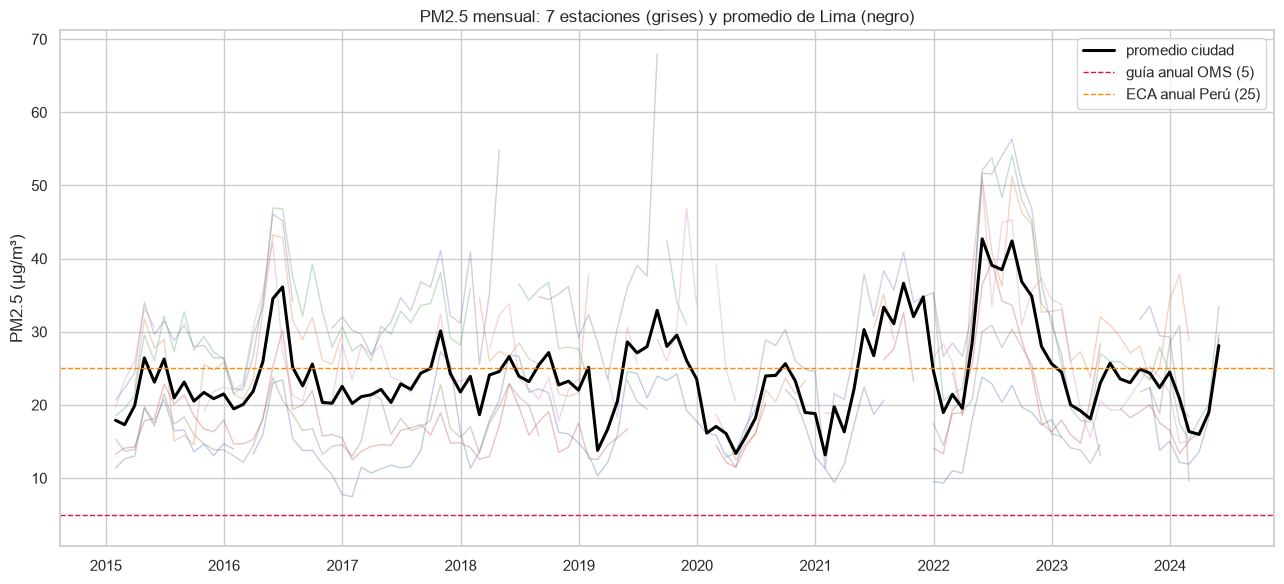

In [3]:
# calcular la media mensual de pm2.5 por estacion y el promedio de la ciudad
base = df.set_index("fecha_hora")
mensual = base.groupby("estacion")["pm2_5"].resample("ME").mean().unstack(level=0)
ciudad = base["pm2_5"].resample("ME").mean()

fig, eje = plt.subplots(figsize=(13, 6))
for estacion in mensual.columns:
    eje.plot(mensual.index, mensual[estacion], alpha=0.35, linewidth=1, label="_nolegend_")
eje.plot(ciudad.index, ciudad.values, color="black", linewidth=2.2, label="promedio ciudad")
eje.axhline(5, color="crimson", linestyle="--", linewidth=1, label="guía anual OMS (5)")
eje.axhline(25, color="darkorange", linestyle="--", linewidth=1, label="ECA anual Perú (25)")
eje.set_ylabel("PM2.5 (µg/m³)")
eje.set_title("PM2.5 mensual: 7 estaciones (grises) y promedio de Lima (negro)")
eje.legend()
plt.tight_layout()
plt.show()

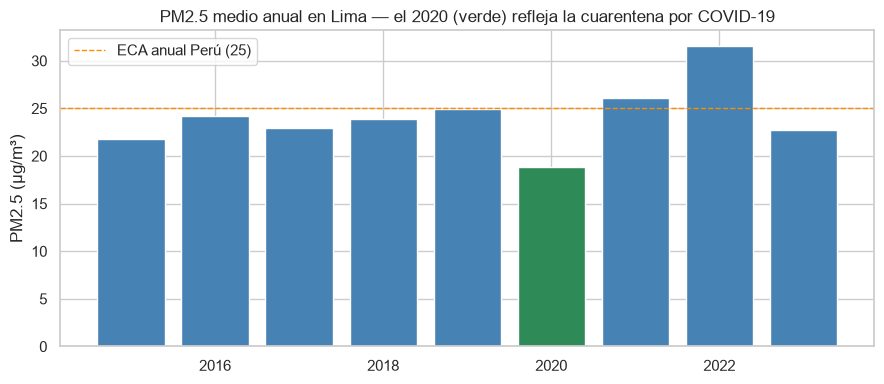

anio
2015    21.8
2016    24.2
2017    22.9
2018    23.9
2019    24.9
2020    18.8
2021    26.1
2022    31.6
2023    22.8
Name: pm2_5, dtype: float64

In [4]:
# calcular la media anual de la ciudad para ver la tendencia (solo anios completos)
anual = df[df.anio < 2024].groupby("anio")["pm2_5"].mean()

fig, eje = plt.subplots(figsize=(9, 4))
colores = ["seagreen" if a == 2020 else "steelblue" for a in anual.index]
eje.bar(anual.index, anual.values, color=colores)
eje.axhline(25, color="darkorange", linestyle="--", linewidth=1, label="ECA anual Perú (25)")
eje.set_ylabel("PM2.5 (µg/m³)")
eje.set_title("PM2.5 medio anual en Lima — el 2020 (verde) refleja la cuarentena por COVID-19")
eje.legend()
plt.tight_layout()
plt.show()
anual.round(1)

En la década no se ve una mejora sostenida. Lo que sí salta es el 2020: 18.8 µg/m³, el año más limpio de la serie. La cuarentena por COVID-19 sacó los autos de la calle y el PM2.5 cayó 25% respecto a 2019. El 2022 aparece como el peor año (31.6); una parte puede ser real y otra depender de qué estaciones estuvieron operativas, así que la comparación entre años hay que tomarla con cuidado.

## 3. Estacionalidad: el peso del invierno

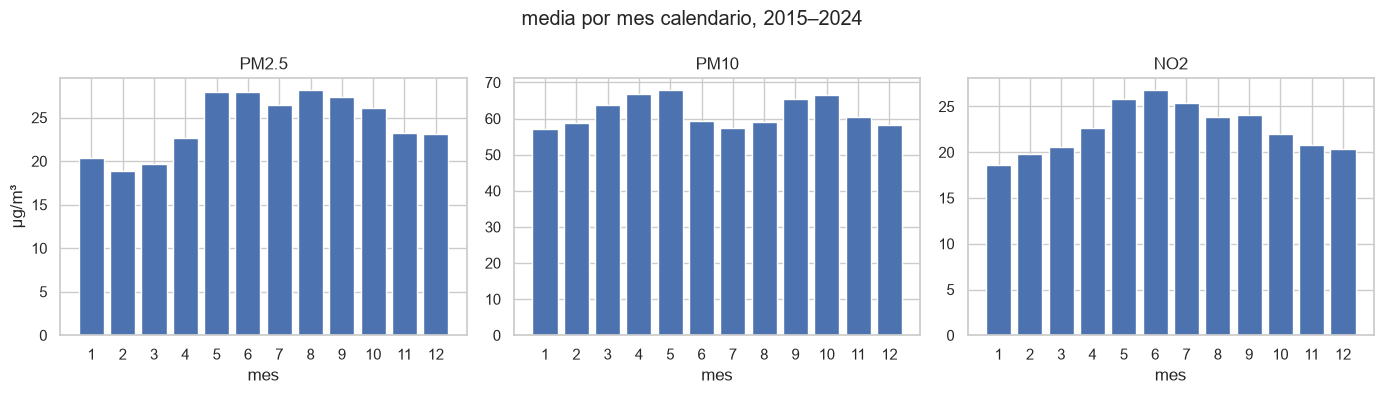

pm2.5 invierno (jun-ago): 27.5 | verano (dic-feb): 20.8 | diferencia: +32%


In [5]:
# comparar el ciclo anual de los tres contaminantes (media por mes calendario)
fig, ejes = plt.subplots(1, 3, figsize=(14, 4))
nombres = {"pm2_5": "PM2.5", "pm10": "PM10", "no2": "NO2"}
for eje, contaminante in zip(ejes, ["pm2_5", "pm10", "no2"]):
    por_mes = df.groupby("mes")[contaminante].mean()
    eje.bar(por_mes.index, por_mes.values)
    eje.set_title(nombres[contaminante])
    eje.set_xlabel("mes")
    eje.set_xticks(range(1, 13))
ejes[0].set_ylabel("µg/m³")
fig.suptitle("media por mes calendario, 2015–2024")
plt.tight_layout()
plt.show()

invierno = df[df.mes.isin([6, 7, 8])]["pm2_5"].mean()
verano = df[df.mes.isin([12, 1, 2])]["pm2_5"].mean()
print(f"pm2.5 invierno (jun-ago): {invierno:.1f} | verano (dic-feb): {verano:.1f} | diferencia: +{100 * (invierno / verano - 1):.0f}%")

PM2.5 y PM10 suben en los meses fríos, de mayo a septiembre, con el pico en agosto. El invierno promedia 32% más PM2.5 que el verano. El porqué es meteorológico y se estudia en el notebook 02.

## 4. Ciclos horario y semanal

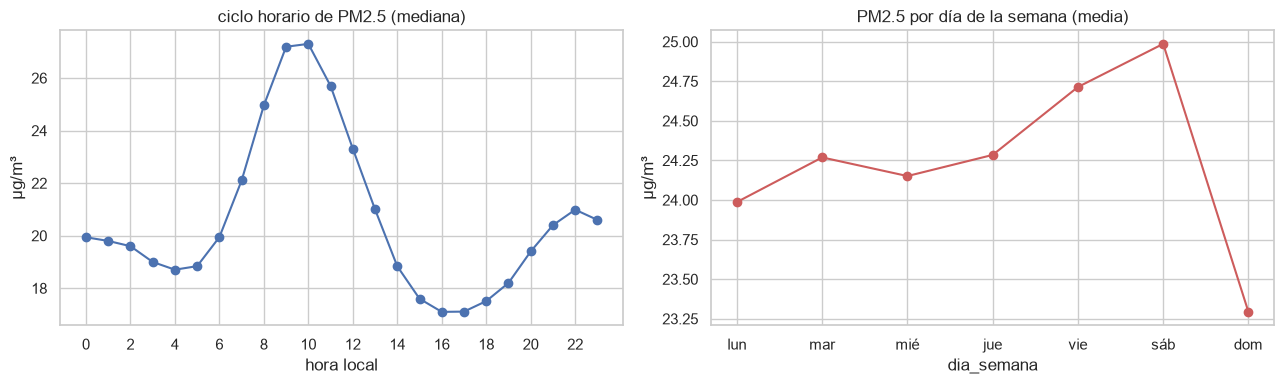

In [6]:
# graficar el ciclo horario (mediana) y el semanal (media)
fig, (eje1, eje2) = plt.subplots(1, 2, figsize=(13, 4))

df.groupby("hora")["pm2_5"].median().plot(ax=eje1, marker="o")
eje1.set_title("ciclo horario de PM2.5 (mediana)")
eje1.set_xlabel("hora local")
eje1.set_ylabel("µg/m³")
eje1.set_xticks(range(0, 24, 2))

dias = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
df.groupby("dia_semana")["pm2_5"].mean().plot(ax=eje2, marker="o", color="indianred")
eje2.set_xticks(range(7), dias)
eje2.set_title("PM2.5 por día de la semana (media)")
eje2.set_ylabel("µg/m³")

plt.tight_layout()
plt.show()

El pico del día es a las 9–10 de la mañana, cuando la hora punta del tráfico coincide con poca ventilación, y el mínimo a las 4–5 de la tarde, cuando la brisa marina limpia la ciudad. El efecto fin de semana existe pero es chico: el domingo baja apenas un 6%. La contaminación de fondo no descansa.

## 5. ¿Cuántos días respiramos aire "malo"?

Se calculan medias diarias solo con días que tienen al menos 18 horas válidas de medición, y se comparan contra la guía OMS 24h (15 µg/m³) y el ECA peruano 24h (50 µg/m³).

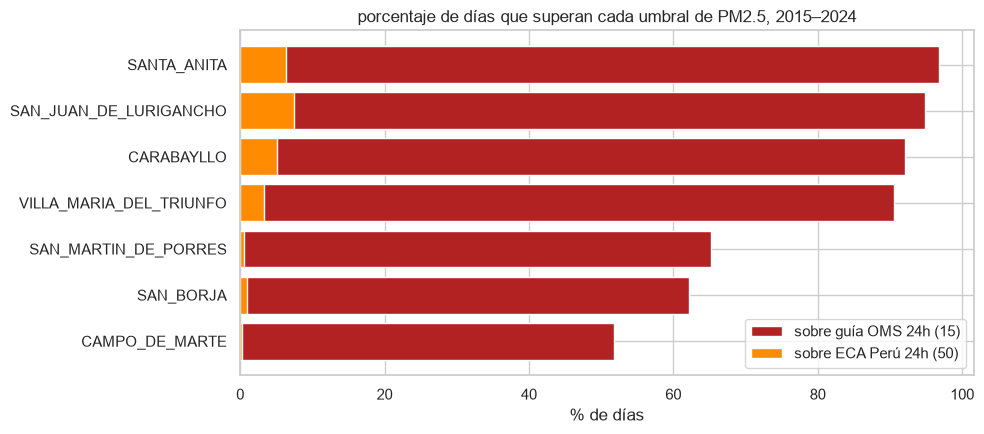

,dias_validos,pct_sobre_oms,pct_sobre_eca
estacion,,,
CAMPO_DE_MARTE,2431,51.7,0.2
SAN_BORJA,2274,62.2,0.9
SAN_MARTIN_DE_PORRES,1857,65.3,0.5
VILLA_MARIA_DEL_TRIUNFO,1912,90.5,3.3
CARABAYLLO,1884,92.0,5.0
SAN_JUAN_DE_LURIGANCHO,2571,94.8,7.4
SANTA_ANITA,2063,96.8,6.3


In [7]:
# calcular medias diarias validas y porcentaje de dias sobre cada umbral
diario = df.groupby(["estacion", df.fecha_hora.dt.date])["pm2_5"].agg(["mean", "count"])
diario = diario[diario["count"] >= 18]
excedencias = (
    diario.groupby("estacion")
    .agg(
        dias_validos=("mean", "size"),
        pct_sobre_oms=("mean", lambda s: 100 * (s > 15).mean()),
        pct_sobre_eca=("mean", lambda s: 100 * (s > 50).mean()),
    )
    .sort_values("pct_sobre_oms")
)

fig, eje = plt.subplots(figsize=(10, 4.5))
eje.barh(excedencias.index, excedencias["pct_sobre_oms"], color="firebrick", label="sobre guía OMS 24h (15)")
eje.barh(excedencias.index, excedencias["pct_sobre_eca"], color="darkorange", label="sobre ECA Perú 24h (50)")
eje.set_xlabel("% de días")
eje.set_title("porcentaje de días que superan cada umbral de PM2.5, 2015–2024")
eje.legend()
plt.tight_layout()
plt.show()
excedencias.round(1)

En San Juan de Lurigancho, Santa Anita, Carabayllo y Villa María del Triunfo, más de 9 de cada 10 días superan lo que la OMS considera aceptable. Hasta la estación más limpia (Campo de Marte) lo hace la mitad de los días. El estándar legal peruano, en cambio, casi nunca se excede: entre 0.2% y 7.4% de los días según la estación. Cumplir la ley no equivale a respirar aire sano; la norma es más de tres veces más laxa que la recomendación sanitaria.

## 6. El evento más extremo del dataset: Año Nuevo

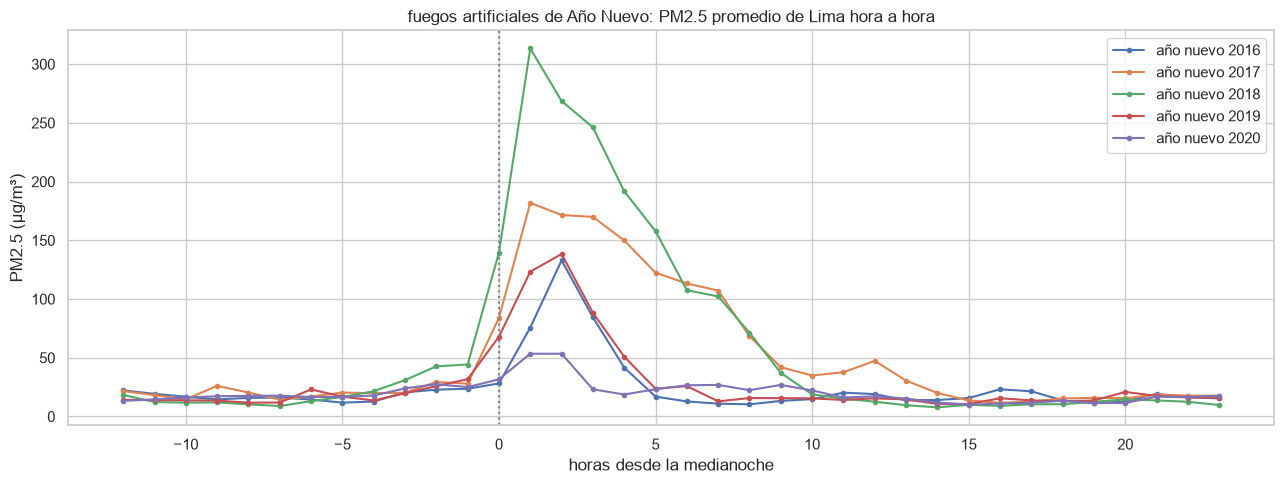

pm2.5 madrugada del 1 de enero: 95 µg/m³ (máx 721)
pm2.5 madrugada típica: 23 µg/m³ → factor 4.0x


In [8]:
# graficar las horas alrededor de la medianoche de anio nuevo (promedio de la ciudad)
por_hora = df.set_index("fecha_hora")["pm2_5"].resample("h").mean()

fig, eje = plt.subplots(figsize=(13, 5))
for anio in [2016, 2017, 2018, 2019, 2020]:
    ventana = por_hora.loc[f"{anio - 1}-12-31 12:00" : f"{anio}-01-01 23:00"]
    horas_relativas = [h - 12 for h in range(len(ventana))]
    eje.plot(horas_relativas, ventana.values, marker=".", label=f"año nuevo {anio}")
eje.axvline(0, color="gray", linestyle=":")
eje.set_xlabel("horas desde la medianoche")
eje.set_ylabel("PM2.5 (µg/m³)")
eje.set_title("fuegos artificiales de Año Nuevo: PM2.5 promedio de Lima hora a hora")
eje.legend()
plt.tight_layout()
plt.show()

madrugada_anio_nuevo = df[(df.mes == 1) & (df.fecha_hora.dt.day == 1) & (df.hora <= 4)]["pm2_5"]
madrugada_tipica = df[df.hora <= 4]["pm2_5"]
print(f"pm2.5 madrugada del 1 de enero: {madrugada_anio_nuevo.mean():.0f} µg/m³ (máx {madrugada_anio_nuevo.max():.0f})")
print(f"pm2.5 madrugada típica: {madrugada_tipica.mean():.0f} µg/m³ → factor {madrugada_anio_nuevo.mean() / madrugada_tipica.mean():.1f}x")

La madrugada del 1 de enero promedia ~95 µg/m³, cuatro veces una madrugada típica, con máximos horarios de hasta 720 µg/m³ (San Juan de Lurigancho, 2018). Estos picos fueron los que delataron que los timestamps del dataset venían en UTC: aparecían a las "5–9 de la mañana" hasta que se corrigió la zona horaria.

## Hallazgos

La OMS recomienda no pasar de 15 µg/m³ de PM2.5 como promedio diario. En cuatro de las siete estaciones eso se incumple más del 90% de los días; hasta en la más limpia ocurre la mitad de los días. La norma peruana casi nunca se excede, pero su límite es tres veces más alto que el de la OMS.

No todos los distritos respiran lo mismo. San Juan de Lurigancho promedia 31 µg/m³ de PM2.5 y Campo de Marte 17. La periferia del este y del norte sale peor parada que el centro.

El invierno tiene 32% más PM2.5 que el verano, con el pico en agosto — y eso que en invierno hay menos actividad al aire libre. La explicación es meteorológica y está en el notebook 02.

En 2020 la cuarentena redujo el PM2.5 en 25% respecto a 2019. Fue el año más limpio de la década y una medida directa del peso del tráfico.

La madrugada de Año Nuevo multiplica por cuatro el PM2.5 de una madrugada normal. Ese patrón, además de ser un hallazgo en sí, sirvió para detectar el problema de zona horaria del dataset oficial.